# Netflix User Churn Prediction

# Problem Statement

> **"Bagaimana platform streaming dapat menekan angka *churn* dengan memahami pola perilaku pengguna dan membangun model prediksi yang akurat?"**

#  Objective
Platform streaming saat ini menghadapi tantangan dalam mempertahankan basis pengguna. Fokus utama project ini adalah:
1. **Identifikasi Perilaku:** Menemukan pola atau anomali pada user yang cenderung berhenti berlangganan.
2. **Prediksi Dini:** Membangun model machine learning untuk mendeteksi potensi *churn* sebelum hal itu terjadi.
3. **Strategi Retensi:** Memberikan rekomendasi berbasis data untuk menjaga loyalitas user.

# Overview & Feature Description
---

Dataset ini berisi **1,000 baris data** dengan **16 kolom** yang mencakup informasi pengguna platform streaming. Berikut adalah rincian variabel yang tersedia:

### User Demographics & Account

| Feature | Type | Description |
| :--- | :--- | :--- |
| **Customer ID** | `Object` | ID unik untuk setiap pelanggan. |
| **Age** | `Integer` | Usia pelanggan. |
| **Monthly Income ($)** | `Integer` | Pendapatan bulanan pelanggan dalam USD. |
| **Region** | `Object` | Lokasi geografis pelanggan. |
| **Subscription Plan** | `Object` | Paket langganan yang dipilih (misal: Basic, Premium, Gold). |

### Usage & Engagement (Behavior)

| Feature | Type | Description |
| :--- | :--- | :--- |
| **Subscription Length (Months)** | `Integer` | Durasi berlangganan dalam hitungan bulan. |
| **Daily Watch Time (Hours)** | `Float` | Rata-rata waktu menonton per hari (jam). |
| **Engagement Rate (1-10)** | `Integer` | Skor tingkat interaksi user di dalam platform. |
| **Device Used Most Often** | `Object` | Perangkat yang paling sering digunakan (Mobile, Smart TV, Laptop, dll). |
| **Genre Preference** | `Object` | Genre konten yang paling diminati pelanggan. |
| **Number of Profiles Created** | `Integer` | Jumlah profil yang dibuat dalam satu akun. |

###  Customer Experience & Loyalty

| Feature | Type | Description |
| :--- | :--- | :--- |
| **Customer Satisfaction Score** | `Integer` | Skor kepuasan pelanggan terhadap layanan (Skala 1-10). |
| **Payment History** | `Object` | Status pembayaran (Tepat waktu atau terlambat). |
| **Support Queries Logged** | `Integer` | Jumlah komplain atau pertanyaan ke customer support. |
| **Promotional Offers Used** | `Integer` | Jumlah penawaran promo yang pernah diklaim user. |

### Target Variable

| Feature | Type | Description |
| :--- | :--- | :--- |
| **Churn Status (Yes/No)** | `Object` | Status apakah pelanggan berhenti berlangganan (**Target Utama**). |

# Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('./dataset/netflix_large_user_data.xlsx')

In [4]:
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns}")

Shape : (1000, 16)
Columns : Index(['Customer ID', 'Subscription Length (Months)',
       'Customer Satisfaction Score (1-10)', 'Daily Watch Time (Hours)',
       'Engagement Rate (1-10)', 'Device Used Most Often', 'Genre Preference',
       'Region', 'Payment History (On-Time/Delayed)', 'Subscription Plan',
       'Churn Status (Yes/No)', 'Support Queries Logged', 'Age',
       'Monthly Income ($)', 'Promotional Offers Used',
       'Number of Profiles Created'],
      dtype='object')


In [5]:
print(f"DataFrame Info : \n{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   object 
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   object 
 6   Genre Preference                    1000 non-null   object 
 7   Region                              1000 non-null   object 
 8   Payment History (On-Time/Delayed)   1000 non-null   object 
 9   Subscription Plan                   1000 non-null   object 
 10  Churn Status (Yes/No)               1000 non-null   object 
 11  Support Queries Logged              1000 non

# Data Preparation

In [6]:
df.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


## Missing Value

In [7]:
df.isnull().sum()

Customer ID                           0
Subscription Length (Months)          0
Customer Satisfaction Score (1-10)    0
Daily Watch Time (Hours)              0
Engagement Rate (1-10)                0
Device Used Most Often                0
Genre Preference                      0
Region                                0
Payment History (On-Time/Delayed)     0
Subscription Plan                     0
Churn Status (Yes/No)                 0
Support Queries Logged                0
Age                                   0
Monthly Income ($)                    0
Promotional Offers Used               0
Number of Profiles Created            0
dtype: int64

## Duplicated

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Churn Status (Yes/No)"].value_counts(normalize=True)

Churn Status (Yes/No)
Yes    0.539
No     0.461
Name: proportion, dtype: float64

## Feature Interaction

In [10]:
plan_mapping = {
    'Basic': 1,
    'Standard': 2,
    'Premium': 3
}

df["watch_x_engagement"] = df["Daily Watch Time (Hours)"] * df["Engagement Rate (1-10)"]
df["income_per_profile"] = df["Monthly Income ($)"] / df["Number of Profiles Created"]
df["income_per_profile"] = df["Monthly Income ($)"] / df["Subscription Plan"].map(plan_mapping)
# df["satisfaction_per_watch"] = df["Customer Satisfaction Score (1-10)"] / df["Daily Watch Time (Hours)"]

In [11]:
df["watch_efficiency"] = df["Daily Watch Time (Hours)"] / df["Subscription Length (Months)"]
df["engagement_per_income"] = df["Engagement Rate (1-10)"] / df["Monthly Income ($)"]
df["profiles_per_month"] = df["Number of Profiles Created"] / df["Subscription Length (Months)"]
df['loyalty_score'] = df["Subscription Length (Months)"] * df["Engagement Rate (1-10)"]
# df["cost_per_watch_hour"] = df["Monthly Income ($)"] / (df["Daily Watch Time (Hours)"] * 30)

In [12]:
df["usage_intensity"] = (
    df["Daily Watch Time (Hours)"] *
    df["Engagement Rate (1-10)"] *
    df["Subscription Length (Months)"]
)
df['suppoort query intensity'] = df["Support Queries Logged"] / (df["Subscription Length (Months)"] + 1)

In [13]:
df["age_group"] = pd.cut(df["Age"], bins=[0,25,40,60,100])
df["income_level"] = pd.cut(df["Monthly Income ($)"], bins=3)

## Coorelation

In [14]:
# Pearson Correlation (Untuk Fitur Angka)
    
df['Churn_Numeric'] = df['Churn Status (Yes/No)'].map({'Yes': 1, 'No': 0})

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
pearson_corr = df[numeric_cols].corr()['Churn_Numeric'].sort_values(ascending=False)

print("Korelasi Pearson terhadap Churn:")
print(pearson_corr)

Korelasi Pearson terhadap Churn:
Churn_Numeric                         1.000000
Support Queries Logged                0.046708
usage_intensity                       0.045442
income_per_profile                    0.031393
Monthly Income ($)                    0.030653
Customer Satisfaction Score (1-10)    0.027909
loyalty_score                         0.026762
Subscription Length (Months)          0.024079
Promotional Offers Used               0.003020
watch_x_engagement                   -0.004930
Daily Watch Time (Hours)             -0.012861
Engagement Rate (1-10)               -0.020569
Number of Profiles Created           -0.022517
suppoort query intensity             -0.025331
engagement_per_income                -0.031800
Age                                  -0.055125
watch_efficiency                     -0.056034
profiles_per_month                   -0.060159
Name: Churn_Numeric, dtype: float64


In [15]:
from scipy.stats import chi2_contingency

cat_cols = [
    'Device Used Most Often', 
    'Genre Preference', 
    'Region', 
    'Payment History (On-Time/Delayed)', 
    'Subscription Plan'
]

print("Hasil Uji Chi-Square (Cek Hubungan ke Churn):")
print("-" * 50)

important_features = []

for col in cat_cols:
    # Buat tabel kontingensi (tabel silang) antara fitur vs target
    contingency_table = pd.crosstab(df[col], df['Churn Status (Yes/No)'])
    
    # Hitung Chi-Square
    # p = p-value (kalo di bawah 0.05 artinya BERPENGARUH)
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    status = "PENTING" if p < 0.05 else "DIBUANG"
    print(f"Fitur: {col:35} | P-Value: {p:.5f} | Status: {status}")
    
    if p < 0.05:
        important_features.append(col)

print("-" * 50)
print(f"Fitur kategori yang wajib lo simpan: {important_features}")

Hasil Uji Chi-Square (Cek Hubungan ke Churn):
--------------------------------------------------
Fitur: Device Used Most Often              | P-Value: 0.31165 | Status: DIBUANG
Fitur: Genre Preference                    | P-Value: 0.63526 | Status: DIBUANG
Fitur: Region                              | P-Value: 0.81170 | Status: DIBUANG
Fitur: Payment History (On-Time/Delayed)   | P-Value: 0.75411 | Status: DIBUANG
Fitur: Subscription Plan                   | P-Value: 0.91674 | Status: DIBUANG
--------------------------------------------------
Fitur kategori yang wajib lo simpan: []


In [16]:
df_test = df['Churn Status (Yes/No)']
df_train = df.drop(columns=['Churn_Numeric','Churn Status (Yes/No)','Customer ID','Subscription Plan','Device Used Most Often', 'Genre Preference', 'Region', 'Payment History (On-Time/Delayed)'])

## Encoding

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_test = le.fit_transform(df_test)
df_test[:5]

array([0, 1, 1, 0, 1])

In [18]:
# Encode categorical variables in the training set
df_train = pd.get_dummies(df_train, drop_first=True)
cols_boolean = df_train.select_dtypes(include='bool').columns
df_train[cols_boolean] = df_train[cols_boolean].astype(int)
df_train.head()

,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created,watch_x_engagement,...,engagement_per_income,profiles_per_month,loyalty_score,usage_intensity,suppoort query intensity,"age_group_(25, 40]","age_group_(40, 60]","age_group_(60, 100]","income_level_(3671.333, 6832.667]","income_level_(6832.667, 9994.0]"
0,12,10,4.85,4,10,33,6250,5,2,19.40,...,0.000640,0.166667,48,232.80,0.769231,1,0,0,1,0
1,12,8,1.75,9,9,28,7018,1,5,15.75,...,0.001282,0.416667,108,189.00,0.692308,1,0,0,0,1
2,3,4,2.75,9,3,18,1055,1,5,24.75,...,0.008531,1.666667,27,74.25,0.750000,0,0,0,0,0
3,3,7,3.00,9,5,32,6707,5,4,27.00,...,0.001342,1.333333,27,81.00,1.250000,1,0,0,1,0
4,24,2,1.37,5,2,59,1506,3,5,6.85,...,0.003320,0.208333,120,164.40,0.080000,0,1,0,0,0


## Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_train)

# Spliting Dataset

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_scaled, df_test, test_size=0.2, random_state=42, stratify=df_test)

In [21]:
print("Shape")
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}") 
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")

Shape
X_train : (800, 22)
X_test : (200, 22)
y_train : (800,)
y_test : (200,)


# Modeling

## Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver='liblinear', penalty='l2', C=0.01, max_iter=1000)
logreg.fit(X_train, y_train)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

## Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, min_samples_split=2, min_samples_leaf=5, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [24]:
X_train

array([[ 1.80449659,  0.21750868,  0.89904843, ..., -0.47010767,
         1.39016234, -0.69705387],
       [-0.75196488, -0.48300236, -0.37589253, ..., -0.47010767,
        -0.71934045, -0.69705387],
       [ 1.80449659, -1.53376893, -0.32212996, ..., -0.47010767,
        -0.71934045,  1.43460935],
       ...,
       [ 1.80449659,  0.21750868, -0.58326245, ...,  2.12717227,
        -0.71934045,  1.43460935],
       [ 1.80449659,  1.61853076, -0.49877841, ..., -0.47010767,
         1.39016234, -0.69705387],
       [-0.9954374 ,  0.91801972, -0.13780115, ..., -0.47010767,
         1.39016234, -0.69705387]], shape=(800, 22))

## XGBoost

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', subsample=0.8, n_estimators=500, max_depth=7, learning_rate=0.105, colsample_bytree=1)
xgb.fit(X_train, y_train)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:01:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

# Hyperparameter

In [26]:
from sklearn.model_selection import RandomizedSearchCV

## Logistic Regression

In [27]:
# log_reg_params = {
#     "C": [0.01, 0.1, 1, 10],
#     "penalty": ["l2"],
#     "solver": ["lbfgs", "liblinear"]
# }

# from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression(max_iter=1000)

# lr_search = RandomizedSearchCV(
#     estimator=lr,
#     param_distributions=log_reg_params,
#     n_iter=10,
#     scoring="roc_auc",
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# lr_search.fit(X_train, y_train)

# print("Best Params:", lr_search.best_params_)
# print("Best CV Score:", lr_search.best_score_)

## Random Forest

In [28]:
# rf_params = {
#     "n_estimators": [100, 200, 500],
#     "max_depth": [3, 5, 10, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4]
# }

# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(random_state=42)

# rf_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=rf_params,
#     n_iter=20,
#     scoring="roc_auc",
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# rf_search.fit(X_train, y_train)

# print("Best Params:", rf_search.best_params_)
# print("Best CV Score:", rf_search.best_score_)

## XGBoost

In [29]:
# from sklearn.model_selection import RandomizedSearchCV

# xgb_params = {
#     "n_estimators": [100, 300, 500],
#     "max_depth": [3, 5, 7],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "subsample": [0.7, 0.8, 1],
#     "colsample_bytree": [0.7, 0.8, 1]
# }

# from sklearn.model_selection import RandomizedSearchCV
# from xgboost import XGBClassifier

# xgb = XGBClassifier(eval_metric="logloss", random_state=42)

# xgb_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=xgb_params,
#     n_iter=20,
#     scoring="roc_auc",
#     cv=3,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# xgb_search.fit(X_train, y_train)

# print("Best Params:", xgb_search.best_params_)
# print("Best CV Score:", xgb_search.best_score_)

# Evaluation

In [30]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score

## Logistic Regression

In [31]:
logreg_pred = logreg.predict(X_test)

accuracy_logreg = accuracy_score(y_test, logreg_pred)
roc_auc_logreg = roc_auc_score(y_test, logreg_pred)
print(f"Logistic Regression Accuracy: {accuracy_logreg:.4f}")
print(f"Logistic Regression ROC AUC: {roc_auc_logreg:.4f}")
print(f"Classification Report :")
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 0.5250
Logistic Regression ROC AUC: 0.5079
Classification Report :
              precision    recall  f1-score   support

           0       0.47      0.29      0.36        92
           1       0.55      0.72      0.62       108

    accuracy                           0.53       200
   macro avg       0.51      0.51      0.49       200
weighted avg       0.51      0.53      0.50       200



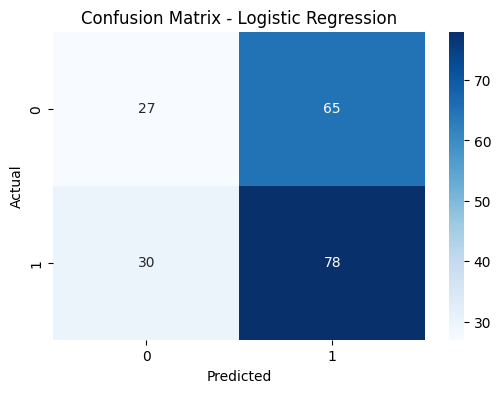

In [32]:
cm_logreg = confusion_matrix(y_test, logreg_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Forest

In [33]:
rf_pred = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, rf_pred)
roc_auc_rf = roc_auc_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest ROC AUC: {roc_auc_rf:.4f}")
print(f"Classification Report :")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5450
Random Forest ROC AUC: 0.5199
Classification Report :
              precision    recall  f1-score   support

           0       0.51      0.21      0.29        92
           1       0.55      0.83      0.66       108

    accuracy                           0.55       200
   macro avg       0.53      0.52      0.48       200
weighted avg       0.53      0.55      0.49       200



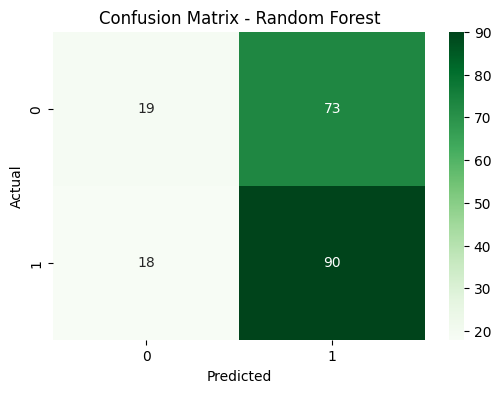

In [34]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## XGBoost

In [35]:
xgb_pred = xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, xgb_pred)
roc_auc_xgb = roc_auc_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost ROC AUC: {roc_auc_xgb:.4f}")
print(f"Classification Report :")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.5450
XGBoost ROC AUC: 0.5433
Classification Report :
              precision    recall  f1-score   support

           0       0.51      0.52      0.51        92
           1       0.58      0.56      0.57       108

    accuracy                           0.55       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.55      0.55      0.55       200



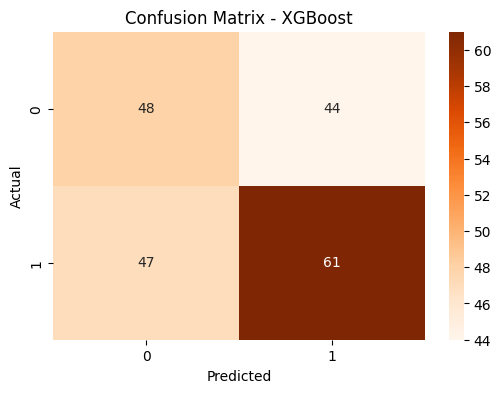

In [36]:
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

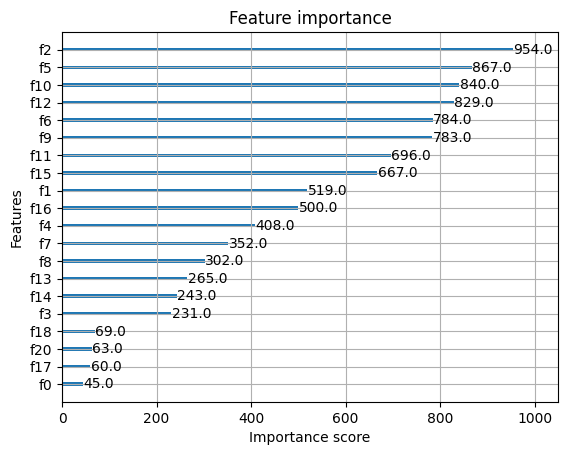

In [37]:
from xgboost import plot_importance

plot_importance(xgb)
plt.show()